In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

import scienceplots
plt.style.use(['science', 'no-latex'])
colors = ["#96A2C3","#DB96C0","#E89676","#71B6A1","#ff9287","#B1AF55","#ff8234ff","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]

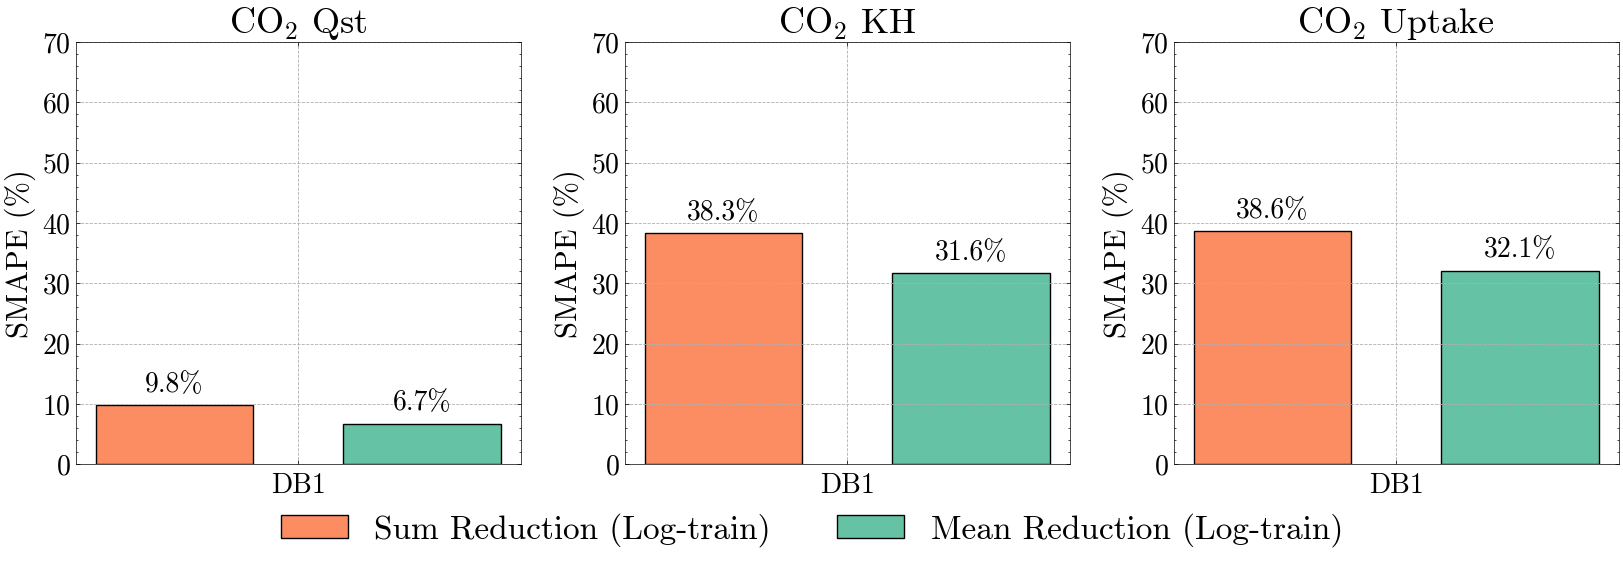

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scienceplots

# ---------- STYLE ----------
plt.style.use(['science', 'no-latex'])
colors = sns.color_palette("Set2", 8)
plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 24,
})

# Training type colors
training_type_colors = {
    "Sum":   colors[1],
    "Mean":  colors[0],
}

# ---------- RAW DATA (SMAPE %) ----------
sum_qst_co2_smape_pct = 9.75
sum_kh_co2_smape_pct     = 38.31
sum_co2_uptake_smape_pct    = 38.61

mean_qst_co2_smape_pct = 6.67
mean_kh_co2_smape_pct     = 31.65
mean_co2_uptake_smape_pct    = 32.07

df = pd.DataFrame({
    'features': ['Sum', 'Mean'],
    'val/co2_uptake_smape_pct': [sum_co2_uptake_smape_pct,  mean_co2_uptake_smape_pct],
    'val/kh_co2_smape_pct':     [sum_kh_co2_smape_pct,      mean_kh_co2_smape_pct],
    'val/qst_co2_smape_pct':    [sum_qst_co2_smape_pct,     mean_qst_co2_smape_pct],
})

# Long format for grouped-bar loop
metric_keys = ['val/qst_co2_smape_pct', 'val/kh_co2_smape_pct', 'val/co2_uptake_smape_pct']
metric_rename = {
    'val/qst_co2_smape_pct': r'CO$_2$ Qst',
    'val/kh_co2_smape_pct':  r'CO$_2$ KH',
    'val/co2_uptake_smape_pct': r'CO$_2$ Uptake',
}
rows = []
for mk in metric_keys:
    for i, feat in enumerate(df['features']):
        rows.append({
            "metric": mk,
            "training_type": feat,
            "value": float(df.loc[i, mk]),
            "group": "DB1",  # single group/tag
        })
plot_df = pd.DataFrame(rows)

# ---------- BAR LAYOUT ----------
bar_width     = 0.14
bar_spacing   = 0.22
group_spacing = 0.70

def annotate_bars(ax, rects, fmt="{:.1f}", dy=None, fontsize=20):
    ymax = ax.get_ylim()[1]
    if dy is None:
        dy = 0.018 * ymax
    for r in rects:
        h = r.get_height()
        ax.text(r.get_x() + r.get_width()/2, h + dy, fmt.format(h),
                ha="center", va="bottom", fontsize=fontsize)

# ---------- DRAW ----------
fig, axs = plt.subplots(1, len(metric_keys),
                        figsize=(5.6 * len(metric_keys), 5.6),
                        sharey=False)

for ax, mk in zip(axs, metric_keys):
    rects = []
    xtick_positions, xtick_labels = [], []
    current_pos = 0.0

    gdf = plot_df[plot_df["metric"] == mk]
    # one group "DB1"
    for j, ttype in enumerate(["Sum", "Mean"]):
        entry = gdf[gdf["training_type"] == ttype]
        if not entry.empty:
            val = float(entry["value"].values[0])
            xpos = current_pos + j * bar_spacing
            rect = ax.bar(
                xpos, val, bar_width,
                color=training_type_colors[ttype],
                edgecolor="black"
            )[0]
            rects.append(rect)

    # center tick between the two bars
    xtick_positions.append(current_pos + bar_spacing / 2)
    xtick_labels.append("DB1")

    # y, labels, grid
    ax.set_ylim([0, 70])
    ax.set_title(metric_rename[mk])
    ax.set_ylabel("SMAPE (%)")
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis="x", pad=6)
    ax.grid(True, linestyle="--", linewidth=0.6)

    annotate_bars(ax, rects, fmt="{:.1f}%", fontsize=20)

# Legend patches
legend_patches = [
    Patch(facecolor=training_type_colors["Sum"],  label='Sum Reduction (Log-train)',  edgecolor="black"),
    Patch(facecolor=training_type_colors["Mean"], label='Mean Reduction (Log-train)', edgecolor="black"),
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

fig.tight_layout()
fig.savefig("mean_vs_sum_smape.png", dpi=300, bbox_inches="tight")
plt.show()
